# 04. Multiclass Defect Pattern Classification

이 노트북에서는 `pattern` wafer만 대상으로 세부 불량 패턴을 분류하는 CNN 모델을 학습한다.

이전 단계에서는 wafer map이 `non_pattern`인지 `pattern`인지 구분하는 이진 분류를 수행했다. 이번 단계에서는 pattern wafer 내부에서 Center, Edge-Ring, Edge-Loc, Loc, Scratch, Random, Donut, Near-full과 같은 세부 공간 불량 패턴을 분류한다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from skimage.transform import resize

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
data_path = Path("../data/raw/LSWMD.pkl")

df = pd.read_pickle(data_path)

print("데이터 크기:", df.shape)
print("컬럼 목록:")
print(df.columns)

데이터 크기: (811457, 6)
컬럼 목록:
Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')


In [4]:
df_labeled = df[df["failureType"].astype(str) != "[]"].copy()

def extract_label(value):
    return value[0][0]

df_labeled["failure_label"] = df_labeled["failureType"].apply(extract_label)
df_labeled["set_label"] = df_labeled["trianTestLabel"].apply(extract_label)

df_pattern = df_labeled[df_labeled["failure_label"] != "none"].copy()

print("pattern wafer 수:", len(df_pattern))

print("\nfailure_label 분포:")
print(df_pattern["failure_label"].value_counts())

print("\nset_label 분포:")
print(df_pattern["set_label"].value_counts())

pattern wafer 수: 25519

failure_label 분포:
failure_label
Edge-Ring    9680
Edge-Loc     5189
Center       4294
Loc          3593
Scratch      1193
Random        866
Donut         555
Near-full     149
Name: count, dtype: int64

set_label 분포:
set_label
Training    17625
Test         7894
Name: count, dtype: int64


In [5]:
def resize_wafer_map(wafer_map, target_size=(32, 32)):
    wafer_map = np.array(wafer_map)

    resized = resize(
        wafer_map,
        target_size,
        order=0,
        preserve_range=True,
        anti_aliasing=False
    ).astype(int)

    return resized

resized_pattern_maps = df_pattern["waferMap"].apply(resize_wafer_map)

X_pattern = np.stack(resized_pattern_maps.values)
X_pattern = X_pattern[..., np.newaxis]
X_pattern = X_pattern / 2.0

y_multiclass = df_pattern["failure_label"].values

print("X_pattern shape:", X_pattern.shape)
print("y_multiclass shape:", y_multiclass.shape)

print("\ny_multiclass 분포:")
print(pd.Series(y_multiclass).value_counts())

X_pattern shape: (25519, 32, 32, 1)
y_multiclass shape: (25519,)

y_multiclass 분포:
Edge-Ring    9680
Edge-Loc     5189
Center       4294
Loc          3593
Scratch      1193
Random        866
Donut         555
Near-full     149
Name: count, dtype: int64


In [6]:
train_mask = df_pattern["set_label"] == "Training"
test_mask = df_pattern["set_label"] == "Test"

X_train_multi = X_pattern[train_mask.values]
X_test_multi = X_pattern[test_mask.values]

y_train_multi_label = y_multiclass[train_mask.values]
y_test_multi_label = y_multiclass[test_mask.values]

multi_encoder = LabelEncoder()

y_train_multi = multi_encoder.fit_transform(y_train_multi_label)
y_test_multi = multi_encoder.transform(y_test_multi_label)

print("X_train_multi shape:", X_train_multi.shape)
print("X_test_multi shape:", X_test_multi.shape)

print("\nclass mapping:")
for idx, name in enumerate(multi_encoder.classes_):
    print(idx, ":", name)

print("\ny_train_multi 분포:")
print(pd.Series(y_train_multi_label).value_counts())

print("\ny_test_multi 분포:")
print(pd.Series(y_test_multi_label).value_counts())

X_train_multi shape: (17625, 32, 32, 1)
X_test_multi shape: (7894, 32, 32, 1)

class mapping:
0 : Center
1 : Donut
2 : Edge-Loc
3 : Edge-Ring
4 : Loc
5 : Near-full
6 : Random
7 : Scratch

y_train_multi 분포:
Edge-Ring    8554
Center       3462
Edge-Loc     2417
Loc          1620
Random        609
Scratch       500
Donut         409
Near-full      54
Name: count, dtype: int64

y_test_multi 분포:
Edge-Loc     2772
Loc          1973
Edge-Ring    1126
Center        832
Scratch       693
Random        257
Donut         146
Near-full      95
Name: count, dtype: int64


In [7]:
num_classes = len(multi_encoder.classes_)

multi_cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 1)),

    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

multi_cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

multi_cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,112 (309.03 KB)

 Trainable params: 79,112 (309.03 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = multi_cnn_model.fit(
    X_train_multi,
    y_train_multi,
    validation_split=0.2,
    epochs=5,
    batch_size=128,
    verbose=1
)

Epoch 1/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6057 - loss: 1.2018 - val_accuracy: 0.1909 - val_loss: 1.5231
Epoch 2/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7300 - loss: 0.7197 - val_accuracy: 0.7064 - val_loss: 1.1390
Epoch 3/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7881 - loss: 0.5828 - val_accuracy: 0.4525 - val_loss: 1.1975
Epoch 4/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8182 - loss: 0.4978 - val_accuracy: 0.8201 - val_loss: 0.6483
Epoch 5/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8338 - loss: 0.4535 - val_accuracy: 0.7881 - val_loss: 0.7366


In [9]:
y_proba_multi = multi_cnn_model.predict(X_test_multi)
y_pred_multi = np.argmax(y_proba_multi, axis=1)

print("Multiclass CNN Classification Report:")
print(classification_report(
    y_test_multi,
    y_pred_multi,
    target_names=multi_encoder.classes_
))

print("Confusion Matrix:")
print(confusion_matrix(y_test_multi, y_pred_multi))

247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Multiclass CNN Classification Report:
              precision    recall  f1-score   support

      Center       0.64      0.58      0.61       832
       Donut       0.40      0.77      0.53       146
    Edge-Loc       0.49      0.69      0.57      2772
   Edge-Ring       0.56      0.87      0.68      1126
         Loc       0.42      0.14      0.21      1973
   Near-full       0.00      0.00      0.00        95
      Random       0.45      0.91      0.60       257
     Scratch       0.00      0.00      0.00       693

    accuracy                           0.51      7894
   macro avg       0.37      0.49      0.40      7894
weighted avg       0.45      0.51      0.44      7894

Confusion Matrix:
[[ 481   17  231   45   46    0   12    0]
 [   4  112   12    4    1    0   13    0]
 [  30    6 1926  584  138    0   88    0]
 [   1    0  137  974    8    0    6    0]
 [ 194  138 1179   92  278    0   92    0]
 [   1    0   21    0    0    0   73 

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [10]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_multi),
    y=y_train_multi
)

class_weight_dict = {
    i: weight for i, weight in enumerate(class_weights)
}

print("Class weight:")
for class_index, weight in class_weight_dict.items():
    print(multi_encoder.classes_[class_index], ":", weight)

Class weight:
Center : 0.6363734835355286
Donut : 5.38661369193154
Edge-Loc : 0.9115122052130741
Edge-Ring : 0.25755494505494503
Loc : 1.3599537037037037
Near-full : 40.798611111111114
Random : 3.6176108374384235
Scratch : 4.40625


In [11]:
weighted_multi_cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 1)),

    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

weighted_multi_cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_weighted = weighted_multi_cnn_model.fit(
    X_train_multi,
    y_train_multi,
    validation_split=0.2,
    epochs=5,
    batch_size=128,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4419 - loss: 1.7001 - val_accuracy: 0.1614 - val_loss: 2.5921
Epoch 2/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6596 - loss: 1.1635 - val_accuracy: 0.1169 - val_loss: 2.1678
Epoch 3/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7123 - loss: 0.8898 - val_accuracy: 0.1850 - val_loss: 2.1484
Epoch 4/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7348 - loss: 0.7904 - val_accuracy: 0.2513 - val_loss: 1.6789
Epoch 5/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7644 - loss: 0.7072 - val_accuracy: 0.6942 - val_loss: 1.1330


In [12]:
y_proba_multi_weighted = weighted_multi_cnn_model.predict(X_test_multi)
y_pred_multi_weighted = np.argmax(y_proba_multi_weighted, axis=1)

print("Weighted Multiclass CNN Classification Report:")
print(classification_report(
    y_test_multi,
    y_pred_multi_weighted,
    target_names=multi_encoder.classes_,
    zero_division=0
))

print("Confusion Matrix:")
print(confusion_matrix(y_test_multi, y_pred_multi_weighted))

247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Weighted Multiclass CNN Classification Report:
              precision    recall  f1-score   support

      Center       0.45      0.18      0.26       832
       Donut       0.42      0.74      0.53       146
    Edge-Loc       0.47      0.58      0.52      2772
   Edge-Ring       0.63      0.62      0.62      1126
         Loc       0.61      0.16      0.25      1973
   Near-full       0.36      1.00      0.53        95
      Random       0.81      0.38      0.52       257
     Scratch       0.19      0.50      0.27       693

    accuracy                           0.43      7894
   macro avg       0.49      0.52      0.44      7894
weighted avg       0.51      0.43      0.42      7894

Confusion Matrix:
[[ 153   21  344   19   44    4    2  245]
 [  11  108   10    1    9    4    3    0]
 [   7   10 1610  347   56   47   11  684]
 [   2    1  340  699    4    0    0   80]
 [ 152  111  849   29  315   21    7  489]
 [   0    0    0    0    0  

In [13]:
multi_compare = pd.DataFrame([
    {
        "model": "CNN",
        "accuracy": 0.51,
        "macro_f1": 0.40,
        "weighted_f1": 0.44,
        "near_full_recall": 0.00,
        "scratch_recall": 0.00
    },
    {
        "model": "Weighted CNN",
        "accuracy": 0.43,
        "macro_f1": 0.44,
        "weighted_f1": 0.42,
        "near_full_recall": 1.00,
        "scratch_recall": 0.50
    }
])

display(multi_compare)

,model,accuracy,macro_f1,weighted_f1,near_full_recall,scratch_recall
0,CNN,0.51,0.40,0.44,0.0,0.0
1,Weighted CNN,0.43,0.44,0.42,1.0,0.5


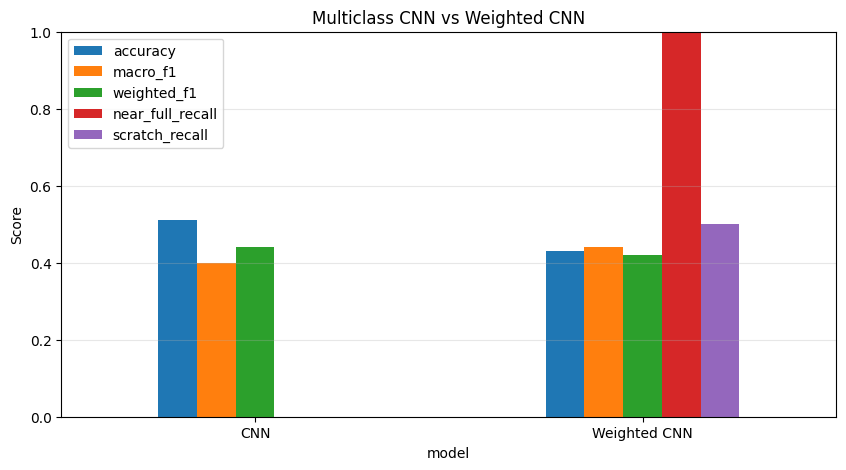

In [14]:
multi_compare.set_index("model")[["accuracy", "macro_f1", "weighted_f1", "near_full_recall", "scratch_recall"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Multiclass CNN vs Weighted CNN")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()